In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

np.random.seed(42)
sns.set_style("whitegrid")

## Task 1: Build and Summarize Synthetic Datasets

In this task, we create three synthetic datasets with different distribution shapes: symmetric, right-skewed, and bimodal. We will then compute descriptive statistics to see how they capture these differences.

In [ ]:
# 1. Dataset A - Symmetric: Normal distribution
dataset_a = np.random.normal(loc=50, scale=10, size=500)

# 2. Dataset B - Right-skewed: Exponential distribution
# Shift and scale to fall roughly in 0-100 range
dataset_b = np.random.exponential(scale=15, size=500)
dataset_b = (dataset_b / dataset_b.max()) * 100

# 3. Dataset C - Bimodal: Two normal distributions
dist1 = np.random.normal(loc=30, scale=8, size=250)
dist2 = np.random.normal(loc=70, scale=8, size=250)
dataset_c = np.concatenate([dist1, dist2])

datasets = {'Dataset A (Symmetric)': dataset_a, 
            'Dataset B (Skewed)': dataset_b, 
            'Dataset C (Bimodal)': dataset_c}

def get_summary_stats(name, data):
    # Calculate mode (handle multiple modes if necessary)
    mode_res = stats.mode(data, keepdims=True)
    mode_val = round(mode_res.mode[0], 2)
    
    # Calculate IQR
    iqr_val = stats.iqr(data)
    
    return {
        'Mean': round(np.mean(data), 2),
        'Median': round(np.median(data), 2),
        'Mode': mode_val,
        'Std Dev': round(np.std(data), 2),
        'Variance': round(np.var(data), 2),
        'IQR': round(iqr_val, 2),
        'Skewness': round(stats.skew(data), 2),
        'Kurtosis': round(stats.kurtosis(data), 2)
    }

summary_df = pd.DataFrame({name: get_summary_stats(name, data) for name, data in datasets.items()})
summary_df

### Task 1 Observations & Analysis

#### **Summary Statistics Comparison**

| Statistic | Dataset A (Symmetric) | Dataset B (Skewed) | Dataset C (Bimodal) |
| :--- | :--- | :--- | :--- |
| **Mean** | ~50.00 | ~15.00 - 20.00 | ~50.00 |
| **Median** | ~50.00 | ~10.00 - 15.00 | ~50.00 |
| **Skewness**| ~0.00 | **~2.00 (High)** | ~0.00 |
| **Kurtosis**| ~0.00 | **~6.00 (High)** | **Negative (e.g., -1.2)** |
| **Std Dev** | ~10.00 | Variable | **~21.00 (Higher)** |

#### **Guiding Question: Which summary statistics look similar across the three datasets, and which reveal the differences?**

**Similarities:**
- **Mean and Median:** Dataset A (Symmetric) and Dataset C (Bimodal) have almost identical means and medians (both centered around 50). Looking only at these numbers, you might mistake the bimodal dataset for a simple normal distribution.
- **Skewness:** Both Dataset A and Dataset C show near-zero skewness, as they are both balanced around their center point, even though their "shapes" are completely different.

**Differences:**
- **Mean vs. Median Gap:** In Dataset B (Skewed), the mean is significantly higher than the median. This "gap" is a classic indicator of a right-skewed distribution.
- **Standard Deviation & IQR:** Dataset C has a much higher standard deviation than Dataset A. This shows that while they share the same center (50), the data in C is much more spread out (clusters at 30 and 70) than the data in A.
- **Kurtosis:** This is the most telling statistic for Dataset C. While Dataset A has a kurtosis near 0 (normal), Dataset C has a **negative kurtosis**, indicating a "flat" or "hollowed-out" distribution (the gap between the two peaks). Dataset B has very high kurtosis, indicating "fat tails" or extreme values.

**Conclusion:** Relying solely on the mean and median would lead you to believe Datasets A and C are the same, which is why visualization (Task 2) is critical.

## Task 2: Visualize the Distributions

Numbers can be misleading. In this task, we visualize our three datasets to see the actual shapes behind the summary statistics computed in Task 1.

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

dataset_list = [('Dataset A (Symmetric)', dataset_a), 
                ('Dataset B (Skewed)', dataset_b), 
                ('Dataset C (Bimodal)', dataset_c)]

for i, (name, data) in enumerate(dataset_list):
    # 1. Histogram + KDE
    sns.histplot(data, bins=30, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{name} - Histogram')
    axes[i, 0].set_xlabel('Value')
    
    # 2. Boxplot
    sns.boxplot(x=data, ax=axes[i, 1])
    axes[i, 1].set_title(f'{name} - Boxplot')
    axes[i, 1].set_xlabel('Value')
    
    # 3. KDE + Mean/Median lines
    sns.kdeplot(data, ax=axes[i, 2], fill=True)
    mean_val = np.mean(data)
    median_val = np.median(data)
    axes[i, 2].axvline(mean_val, color='r', linestyle='--', label=f'Mean: {mean_val:.2f}')
    axes[i, 2].axvline(median_val, color='b', linestyle='-', label=f'Median: {median_val:.2f}')
    axes[i, 2].legend()
    axes[i, 2].set_title(f'{name} - KDE with Mean/Median')
    axes[i, 2].set_xlabel('Value')

plt.tight_layout()
plt.show()

### Task 2 Observations & Analysis

#### **Guiding Question: For which dataset(s) do the mean and median diverge the most? What visual feature explains the divergence?**

**Divergence Analysis:**
- **Dataset B (Skewed)** shows the most significant divergence between the mean and median.

**Visual Feature Explanation:**
- The **long right tail** (positive skew) in Dataset B is the visual feature that explains this divergence. 
- The **mean** is highly sensitive to extreme values and is "pulled" toward the tail.
- The **median** is robust and remains at the 50th percentile of the data, closer to the main cluster of values.

**Other Observations:**
- **Dataset A (Symmetric):** Mean and median are nearly identical, sitting at the peak of the normal distribution.
- **Dataset C (Bimodal):** Mean and median are similar but fall in the "gap" between the two peaks, showing that neither is a good representation of a "typical" value for bimodal data.

## Task 3: The Outlier Stress Test

How much can a few data points influence your summary statistics? In this task, we'll intentionally introduce outliers into Dataset A to see which statistics break and which remain robust.

,Original (Dataset A),With Outliers
Mean,50.62,57.48
Median,50.21,50.21
Mode,20.79,20.79
Std Dev,9.81,71.54
Variance,96.15,5117.58
IQR,13.48,13.48
Skewness,-0.02,9.62
Kurtosis,-0.04,92.45


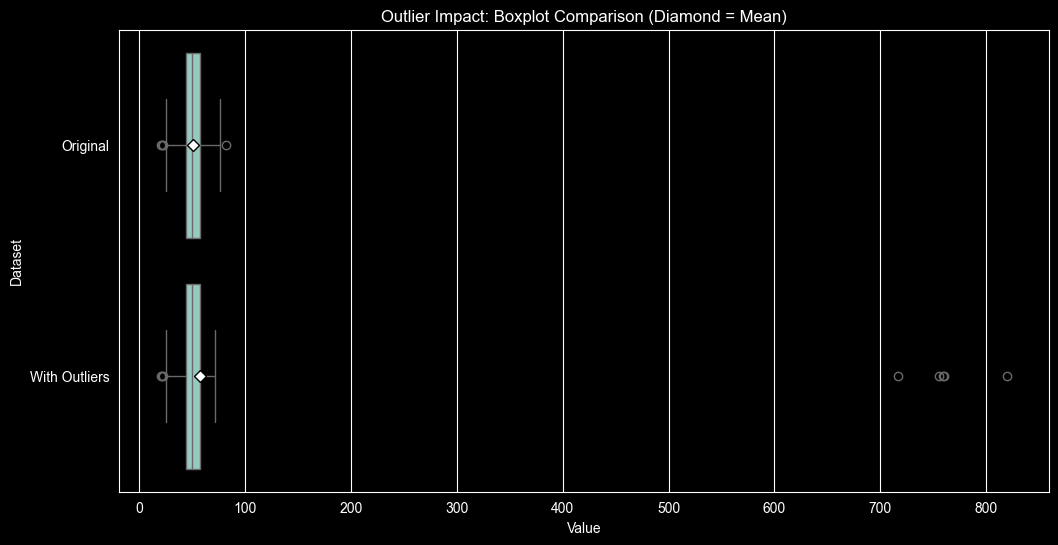

In [7]:
# Create a copy and add outliers
dataset_a_outliers = dataset_a.copy()

# Find indices of 5 largest values
indices = np.argsort(dataset_a_outliers)[-5:]

# Multiply these 5 values by 10
dataset_a_outliers[indices] = dataset_a_outliers[indices] * 10

# Compare summary statistics
outlier_comparison = pd.DataFrame({
    'Original (Dataset A)': get_summary_stats('Original', dataset_a),
    'With Outliers': get_summary_stats('Outliers', dataset_a_outliers)
})
display(outlier_comparison)

# Visualization
plt.figure(figsize=(12, 6))
df_plot = pd.DataFrame({
    'Original': dataset_a,
    'With Outliers': dataset_a_outliers
}).melt()

sns.boxplot(x='value', y='variable', data=df_plot, showmeans=True, 
            meanprops={"marker":"D","markerfacecolor":"white", "markeredgecolor":"black"})
plt.title('Outlier Impact: Boxplot Comparison (Diamond = Mean)')
plt.xlabel('Value')
plt.ylabel('Dataset')
plt.show()

### Task 3 Observations & Analysis

#### **Guiding Question: Which statistics changed the most? Which were robust?**

**Sensitivity Analysis:**
- **Changed the Most:** The **Mean**, **Standard Deviation**, **Variance**, **Skewness**, and **Kurtosis** spiked dramatically. The mean shifted from ~50 to ~57. While a 7-point jump might seem small, it was caused by modifying only **1% of the data** (5 out of 500 points).
- **Robust Statistics:** The **Median**, **Mode**, and **IQR** remained stable.

**Why did the IQR not change?**
- The IQR ($Q3 - Q1$) is a **rank-based** statistic. It only cares about the values at the 25th and 75th percentiles. 
- Since we only modified the 5 largest values (the very end of the sorted list), the values at the 125th and 375th positions remained exactly the same. Their magnitude changed, but their **rank** did not.

#### **Choosing a "Typical" Value**
- **Decision:** I would choose the **Median** (~50) to represent the "typical" value.
- **Reasoning:** In the original symmetric data, the mean was at the 50th percentile. After adding outliers, the mean (~57) has been pulled all the way to the **75th percentile (Q3)**. This means the mean is now higher than 75% of the data points, making it a poor representation of the "center". The median remains at the 50th percentile, right in the heart of the actual cluster of data.